# **Micrograd**

It is a tiny Autograd engine.
- Autograd is Automatic Gradient

It implements backpropogation over a dynamically built DAG ans a small neural networks library on top of it with a PyTorch-like API. 
Both are tiny, but it is enough to build up entire deep neural nets doing binary classification.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5 # A simple quadratic function which makes a Parabola. 

In [3]:
f(5)

60

In [4]:
xs = np.arange(-5, 5, 0.25) # A range of x values from -5 to 5 with a step of 0.25
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [5]:
ys = f(xs) # Compute the corresponding y values for each x using the function f
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

Text(0.5, 1.0, 'Plot of the function f(x)')

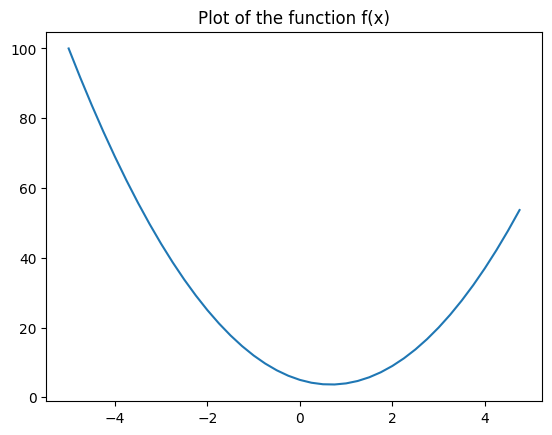

In [6]:
plt.plot(xs, ys) # Plot the x and y values to visualize the function
plt.title('Plot of the function f(x)')

In [7]:
h = 0.00000001 # A small step size for numerical differentiation
x = 3.0 
f(x)


20.0

In [8]:
f(x+h) # Compute the function value at x + h
print("Value of f(x+h):", f(x+h))
f(x-h) # Compute the function value at x - h
print("Value of f(x-h):", f(x-h))

Value of f(x+h): 20.00000014
Value of f(x-h): 19.99999986


In [9]:
(f(x+h) - f(x))/h # Compute the numerical derivative using the forward difference method - slope

14.00000009255109

In [10]:
h = 0.000001 # A small step size for numerical differentiation
x = 2/3
(f(x+h) - f(x))/h # Compute the numerical derivative using the forward difference method - slope

2.999378523327323e-06

In [11]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print("Value of d:", d)

Value of d: 4.0


In [12]:
# Derivative of d with respect to a, b, and c
h = 0.0001

# Inputs
a = 2.0
b = -3.0
c = 10.0

d = a*b + c
a+=h
da_h = a*b + c

print("Original d:", d)
print("d with small perturbation in a:", da_h)

print("Numerical derivative of d with respect to a (Slope):", (da_h - d)/h)
# Slope is negative because d decreases as a increases, which is expected since d = a*b + c and b is negative.

Original d: 4.0
d with small perturbation in a: 3.999699999999999
Numerical derivative of d with respect to a (Slope): -3.000000000010772


In [13]:
# Inputs
a = 2.0
b = -3.0
c = 10.0


d = a*b + c
b+=h
db_h = a*b + c
print("Original d:", d)
print("d with small perturbation in b:", db_h)
print("Numerical derivative of d with respect to b (Slope):", (db_h - d)/h)

Original d: 4.0
d with small perturbation in b: 4.0002
Numerical derivative of d with respect to b (Slope): 2.0000000000042206


In [14]:
# Inputs
a = 2.0
b = -3.0
c = 10.0

d = a*b + c
c+=h
dc_h = a*b + c

print("Original d:", d)
print("d with small perturbation in c:", dc_h)
print("Numerical derivative of d with respect to c (Slope):", (dc_h - d)/h)

Original d: 4.0
d with small perturbation in c: 4.0001
Numerical derivative of d with respect to c (Slope): 0.9999999999976694


In [15]:
class Value:
    def __init__(self, data):
        self.data = data
    
    def __repr__(self):
        return f"Value(data= {self.data})"
    
    def __add__(self, other):
        sum = Value(self.data + other.data)
        return sum
    
    def __mul__(self, other):
        product = Value(self.data * other.data)
        return product
    
    def __sub__(self, other):
        difference = Value(self.data - other.data)
        return difference

In [16]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = Value(5.0)
e = a*b + c - d
e

Value(data= -1.0)

In [22]:
class Value:
    def __init__(self, data, _children =(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # Gradient of this value with respect to some loss function
        self._prev = set(_children) # Set of child nodes that contributed to this value
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data= {self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other)) # Create a new Value for the sum and store the child nodes
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other)) # Create a new Value for the product and store the child nodes
        return out

In [23]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a+b
e.label = 'e'
d = e + c
d.label = 'd'
f = Value(-2.0, label='f')
L = d+ f
L.label = 'L'
print("L: ", L)
print("E: ", e)
print("D: ", d)

L:  Value(data= 7.0)
E:  Value(data= -1.0)
D:  Value(data= 9.0)


In [24]:
d._prev # The child nodes that contributed to the value of D

{Value(data= -1.0), Value(data= 10.0)}

In [25]:
from graphviz import Digraph

def trace(root):
    # Builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr={'rankdir': 'LR'}) # Create a new directed graph with left-to-right orientation
    
    nodes, edges = trace(root) # Get all nodes and edges in the graph
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" %  (n.label, n.data, n.grad), shape = 'record') # Add a node to the graph with a label showing its data value
        if n._op:
            dot.node(name = uid + n._op, label = n._op) # Add a node for the operation that produced this value
            dot.edge(uid + n._op, uid) # Connect the operation node to the value node
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))) # Connect the child nodes to their parent nodes in the graph
    
    return dot

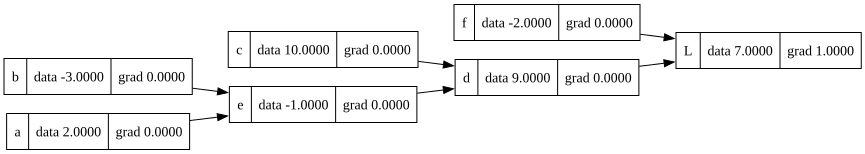

In [33]:
draw_dot(L)

# **Manual Back Propogation**

In [31]:
L.grad = 1.0 # Set the gradient of the output node L to 1.0, as we are interested in how changes in L affect the loss function

L = d * f

We want to know what dL/dd and dL/df are, which will tell us how changes in d and f affect the output L.

(f(x+h) - f(x))/h 
Compute the numerical derivative using the forward difference method - slope

((d+h) * f - d*f)/h

(d* f + h * f - d *f)/h

(h*f)/h

f

In [34]:
f.grad = 4.0
d.grad = -2.0


In [38]:
def lol():

    h = 0.0001 # A small step size for numerical differentiation

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a+b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a+b; e.label = 'e'
    d = e + c; d.label = 'd'
    d.data += h
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data +h

    print("Original L:", L1)
    print("L with small perturbation in a:", L2)
    print((L2 - L1)/h)

lol()

Original L: -18.0
L with small perturbation in a: -18.0001
-0.9999999999976694


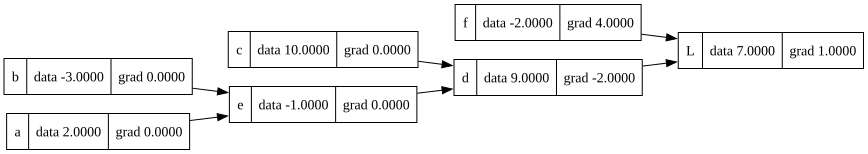

In [39]:
draw_dot(L)

# **Back Propogation**